In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns 
from datetime import date

In [21]:
def load_data(file):
    return pd.read_csv(file, sep = ",", index_col = False, header=0)
df = pd.read_excel('StreamingHistory_music_1.json.xlsx')
df

,endTime,date,weekday,time,artistName,trackName,msPlayed,minPlayed,include song
0,2025-01-12 22:16,2025-01-12,Sun,22:16,Unknown Artist,Unknown Track,348,0.005800,No
1,2025-01-12 22:16,2025-01-12,Sun,22:16,Kacey Musgraves,Space Cowboy,154528,2.575467,Yes
2,2025-01-12 22:44,2025-01-12,Sun,22:44,Billie Eilish,LUNCH,176726,2.945433,Yes
3,2025-01-12 22:46,2025-01-12,Sun,22:46,Sabrina Carpenter,Bed Chem,152949,2.549150,Yes
4,2025-01-12 22:48,2025-01-12,Sun,22:48,Charli xcx,Club classics,144141,2.402350,Yes
...,...,...,...,...,...,...,...,...,...
9995,2025-03-31 18:50,2025-03-31,Mon,18:50,Taylor Swift,New Romantics (Taylor's Version),928,0.015467,No
9996,2025-03-31 18:50,2025-03-31,Mon,18:50,Sabrina Carpenter,Sue Me,998,0.016633,No
9997,2025-03-31 18:50,2025-03-31,Mon,18:50,Kacey Musgraves,Golden Hour,6524,0.108733,No
9998,2025-03-31 18:50,2025-03-31,Mon,18:50,Del Water Gap,Glitter & Honey,1625,0.027083,No


In [22]:
skippedsongs = df[ df['include song'] == "No" ].index #assinging variable to skipped songs
df.drop(skippedsongs, inplace = True)#dropping those skipped songs

In [23]:
df

,endTime,date,weekday,time,artistName,trackName,msPlayed,minPlayed,include song
1,2025-01-12 22:16,2025-01-12,Sun,22:16,Kacey Musgraves,Space Cowboy,154528,2.575467,Yes
2,2025-01-12 22:44,2025-01-12,Sun,22:44,Billie Eilish,LUNCH,176726,2.945433,Yes
3,2025-01-12 22:46,2025-01-12,Sun,22:46,Sabrina Carpenter,Bed Chem,152949,2.549150,Yes
4,2025-01-12 22:48,2025-01-12,Sun,22:48,Charli xcx,Club classics,144141,2.402350,Yes
8,2025-01-13 08:29,2025-01-13,Mon,08:29,Ariana Grande,bye,150000,2.500000,Yes
...,...,...,...,...,...,...,...,...,...
9975,2025-03-31 07:36,2025-03-31,Mon,07:36,Charli xcx,360,123755,2.062583,Yes
9977,2025-03-31 07:40,2025-03-31,Mon,07:40,ROLE MODEL,"Something, Somehow, Someday",215978,3.599633,Yes
9978,2025-03-31 07:42,2025-03-31,Mon,07:42,Charli xcx,Club classics,153526,2.558767,Yes
9981,2025-03-31 07:45,2025-03-31,Mon,07:45,Maggie Rogers,If Now Was Then,179061,2.984350,Yes


In [24]:
df.count()

endTime         3464
date            3464
weekday         3464
time            3464
artistName      3464
trackName       3464
msPlayed        3464
minPlayed       3464
include song    3464
dtype: int64

In [25]:
print(df.shape) #rows,columns


(3464, 9)


In [26]:
#What day of the week are songs streamed the most?
df[['date','weekday','minPlayed']]

,date,weekday,minPlayed
1,2025-01-12,Sun,2.575467
2,2025-01-12,Sun,2.945433
3,2025-01-12,Sun,2.549150
4,2025-01-12,Sun,2.402350
8,2025-01-13,Mon,2.500000
...,...,...,...
9975,2025-03-31,Mon,2.062583
9977,2025-03-31,Mon,3.599633
9978,2025-03-31,Mon,2.558767
9981,2025-03-31,Mon,2.984350


In [27]:
day = ['Mon', 'Tues', 'Wed', 'Thurs', 'Fri', 'Sat','Sun']


In [28]:
#counting up the minutes played each day of week fro the data period
mins=df.groupby('weekday')['minPlayed'].sum().reindex(day)
mins

weekday
Mon      1205.848900
Tues     1646.447367
Wed      2092.760483
Thurs    2497.810250
Fri      1354.769233
Sat      1220.104733
Sun      1470.105500
Name: minPlayed, dtype: float64

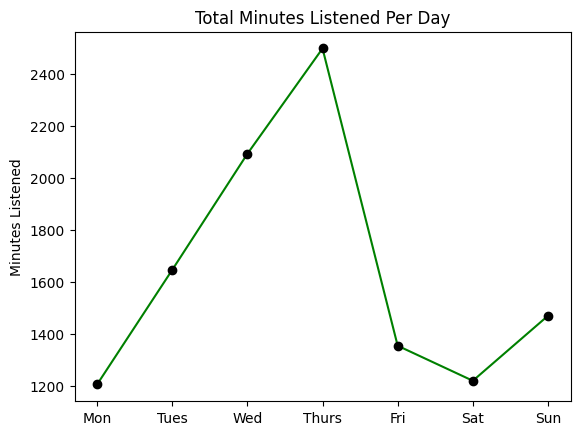

In [29]:
min_day = df.groupby('weekday')['minPlayed'].sum().reindex(day)
plt.plot(min_day, color='Green', marker="o", mfc='black',mec="k")
plt.ylabel('Minutes Listened')
plt.title('Total Minutes Listened Per Day')
plt.show()



In [30]:
#Top 10 Streamed Songs

pd.value_counts(df['trackName'])


/var/folders/wj/mwd6zf295nj8ld04tk35rd240000gn/T/ipykernel_52162/3714537329.py:3: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(df['trackName'])


trackName
Sally, When The Wine Runs Out                                                   64
Juno                                                                            32
Slipfast                                                                        32
360                                                                             31
So High School                                                                  31
                                                                                ..
Does Your Mother Know - From 'Mamma Mia!' Original Motion Picture Soundtrack     1
S.O.S.                                                                           1
Miles On It                                                                      1
Norman fucking Rockwell                                                          1
Maybe I Am                                                                       1
Name: count, Length: 829, dtype: int64

In [31]:
pd.value_counts(df['trackName']).head(10)


/var/folders/wj/mwd6zf295nj8ld04tk35rd240000gn/T/ipykernel_52162/4084249736.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(df['trackName']).head(10)


trackName
Sally, When The Wine Runs Out      64
Juno                               32
Slipfast                           32
360                                31
So High School                     31
Some Protector                     31
That’s So True                     31
Somebody Else - Spotify Singles    30
Packing It Up                      30
Look At That Woman                 29
Name: count, dtype: int64

/var/folders/wj/mwd6zf295nj8ld04tk35rd240000gn/T/ipykernel_52162/1151518941.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(df['trackName']).head(10).plot(kind='bar',color='Green')


Text(0, 0.5, 'Count')

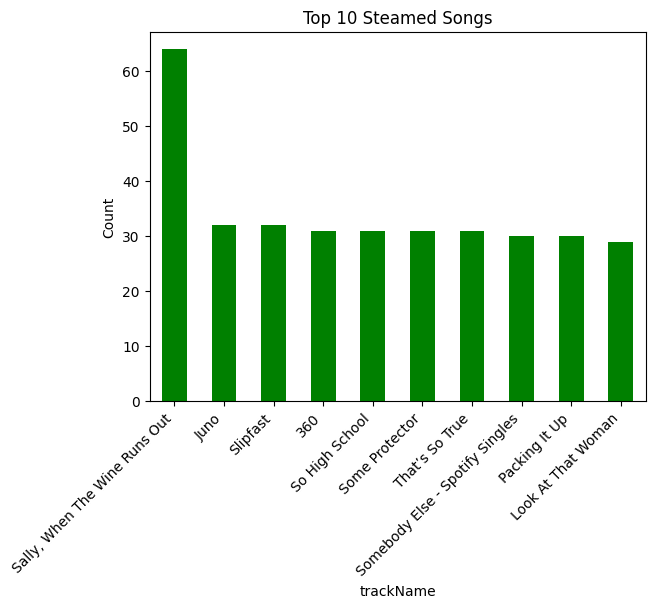

In [32]:
pd.value_counts(df['trackName']).head(10).plot(kind='bar',color='Green')
plt.xticks(rotation=45, ha='right')
plt.title("Top 10 Steamed Songs")
plt.ylabel('Count')


In [ ]:
#Top 20 Steamed Artits
pd.value_counts(df['artistName'])
                

In [ ]:
pd.value_counts(df['artistName']).head(20)

/var/folders/wj/mwd6zf295nj8ld04tk35rd240000gn/T/ipykernel_52162/3640246738.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(df['artistName']).head(20).plot(kind='barh',color='Green')


<Figure size 10000x10000 with 0 Axes>

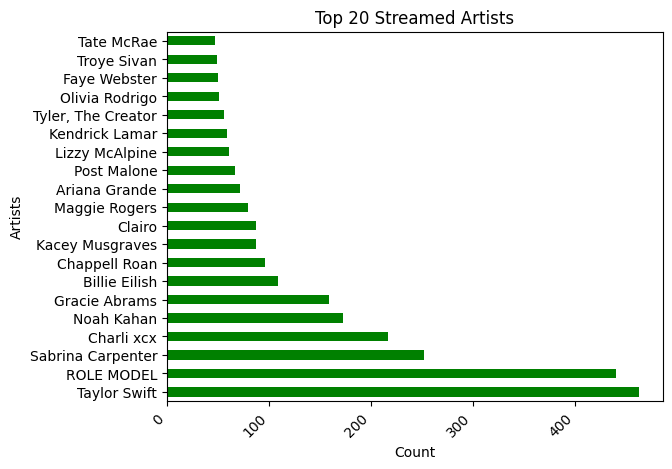

<Figure size 10000x10000 with 0 Axes>

In [34]:
pd.value_counts(df['artistName']).head(20).plot(kind='barh',color='Green')
plt.xticks(rotation=45, ha='right')
plt.title('Top 20 Streamed Artists')
plt.ylabel('Artists')
plt.xlabel('Count')
plt.figure(figsize=(100,100))
